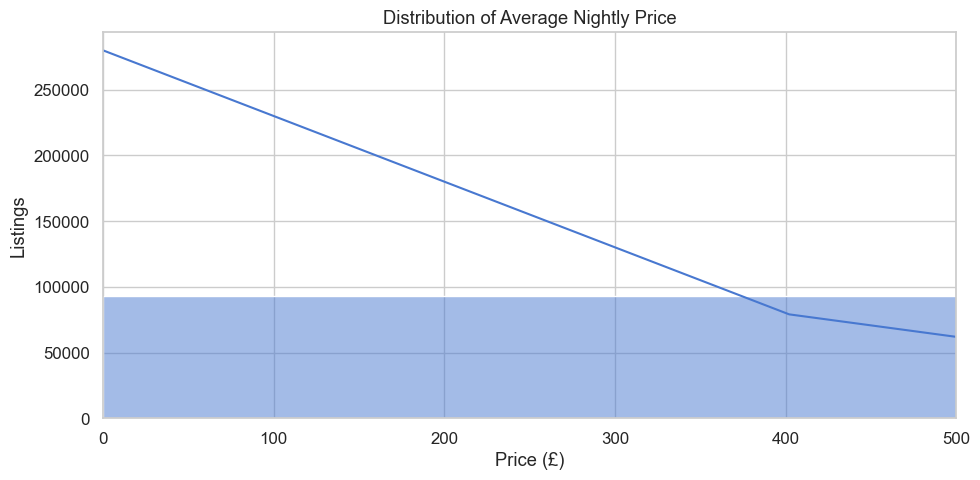

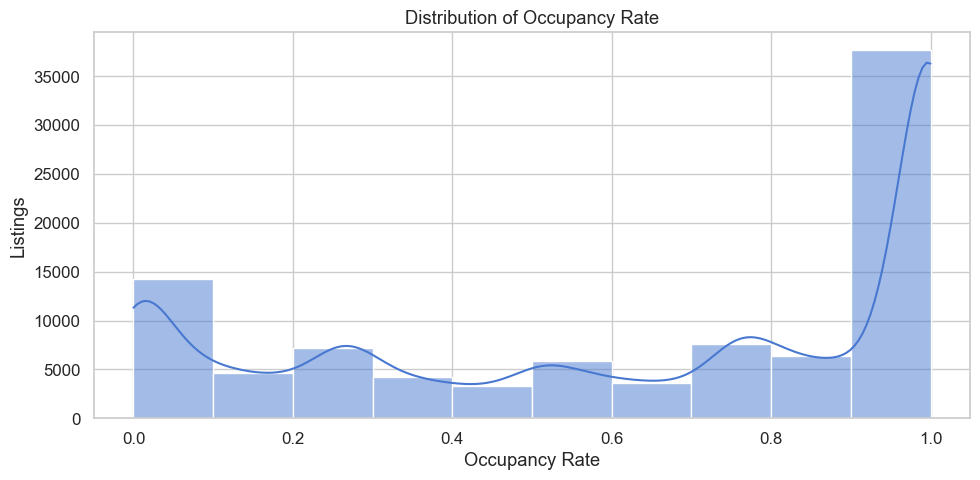

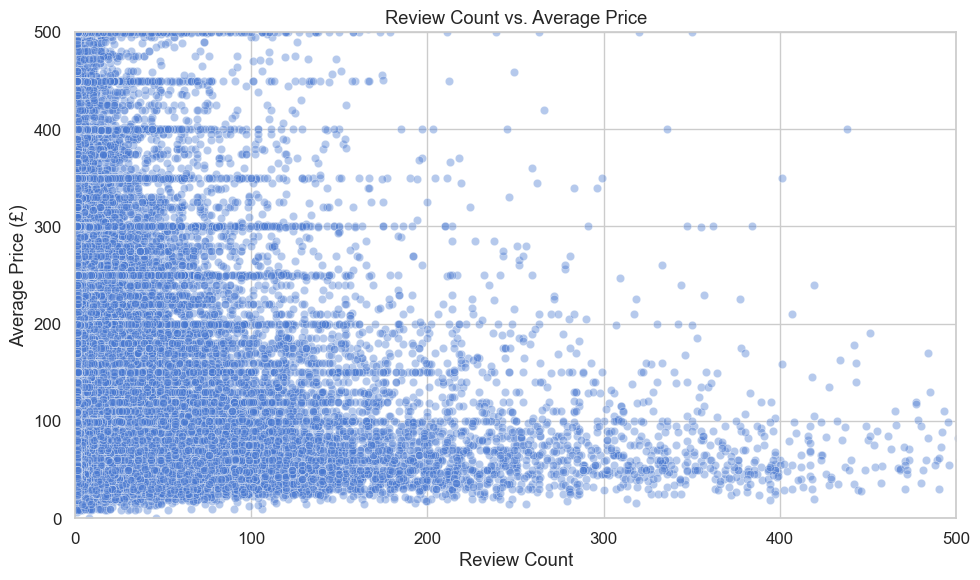

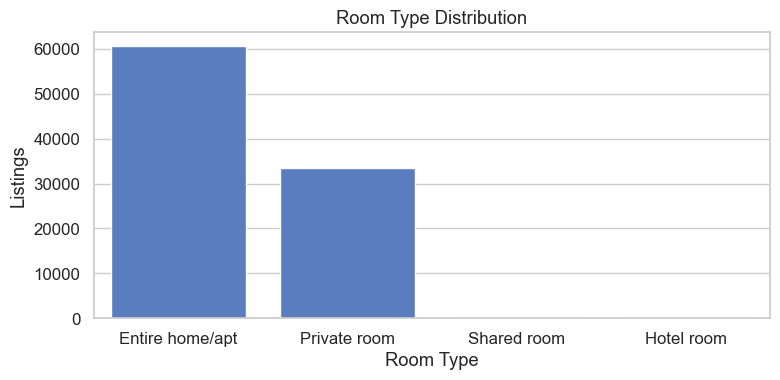

In [1]:
# ---------------------------------------------------------
# GOLD EXPLORATION: Visualize key metrics from listing_features
# Purpose: Understand distribution of price, occupancy, reviews,
# and room types before dashboarding or modeling.
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve project root (assumes notebook is in /notebooks)
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gold_dir = project_root / "data" / "gold"

# Load Gold table
df = pd.read_parquet(gold_dir / "listing_features.parquet")

# Set plot style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# ---------------------------------------------------------
# 1. Distribution of average nightly price
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df["avg_price"], bins=50, kde=True)
plt.title("Distribution of Average Nightly Price")
plt.xlabel("Price (£)")
plt.ylabel("Listings")
plt.xlim(0, 500)  # cap outliers for readability
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Distribution of occupancy rate
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df["occupancy_rate"], bins=10, kde=True)
plt.title("Distribution of Occupancy Rate")
plt.xlabel("Occupancy Rate")
plt.ylabel("Listings")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Review count vs. average price (scatter)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="review_count", y="avg_price", alpha=0.4)
plt.title("Review Count vs. Average Price")
plt.xlabel("Review Count")
plt.ylabel("Average Price (£)")
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Room type breakdown
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index)
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Listings")
plt.tight_layout()
plt.show()

📊 1. Distribution of Average Nightly Price
What it shows:
- A steep drop-off as price increases — most listings are clustered under £100.
- Very few listings priced above £300, suggesting a ceiling in the market.
Why it matters:
- This confirms that the London Airbnb market is price-sensitive.


📊 2. Distribution of Occupancy Rate
What it shows:
- A bimodal distribution: lots of listings are either almost never booked (near 0) or almost always booked (near 1).
- Sparse middle ground — not many listings with moderate occupancy.
Why it matters:
- This is classic in Airbnb data — it reflects two types of hosts:
    - Passive hosts: listings that are rarely available or rarely booked.
    - Active hosts: listings that are consistently booked and managed.


🧠 Strategic Insight
Together, these visuals suggest:
- There’s a sweet spot in pricing — likely under £150 — where listings are more competitive.
- Occupancy is polarised, which opens up opportunities to model what makes a listing successful.

📈 Plot 3: Review Count vs. Average Price (Scatter Plot)
🔍 What it shows:
- A dense cluster of listings with low review counts and low prices — the bottom-left corner is packed.
- As review count increases, price doesn’t necessarily rise — there’s no strong upward trend.
- Sparse data in the upper-right quadrant: few listings with both high price and high review volume.

🏠 Plot 4: Room Type Distribution (Bar Chart)
🔍 What it shows:
- Entire home/apt is the dominant room type — by far the most common.
- Private rooms are the second-largest category.
- Hotel rooms and shared rooms are rare — almost negligible.



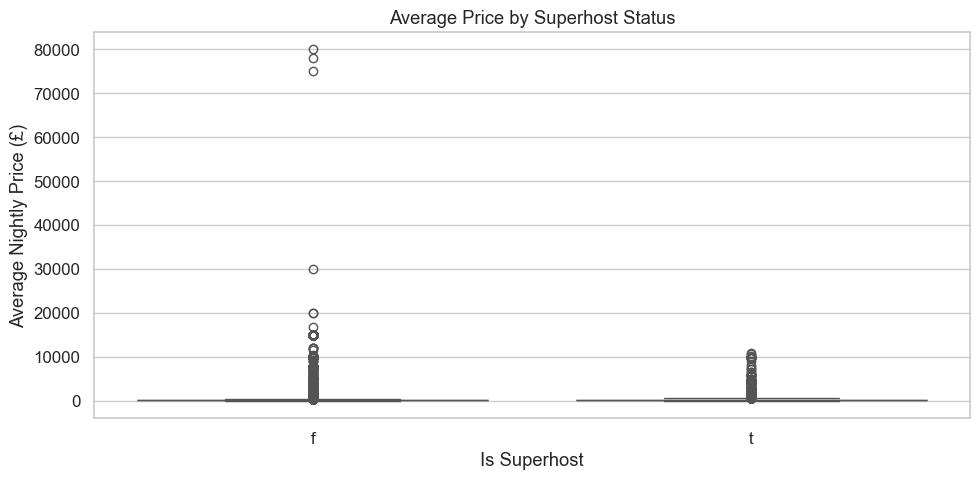

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="host_is_superhost", y="avg_price")
plt.title("Average Price by Superhost Status")
plt.xlabel("Is Superhost")
plt.ylabel("Average Nightly Price (£)")
plt.tight_layout()
plt.show()